In [1]:
!pip install requests beautifulsoup4 pandas lxml tqdm Sastrawi scikit-learn nltk matplotlib


[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm import tqdm
import time
import re
import nltk
import matplotlib.pyplot as plt

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

In [3]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\Assatya
[nltk_data]     Dewantara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
urls = [
    "https://sport.detik.com/sepakbola/liga-inggris",
    "https://sport.detik.com/sepakbola/liga-italia"
]

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/139.0.0.0 Safari/537.36"
}

for url in urls:
    response = requests.get(url, headers=headers, timeout=10)

    print("URL:", url)
    print("Status Code:", response.status_code)
    print("Panjang halaman:", len(response.text))
    print("-" * 50)

URL: https://sport.detik.com/sepakbola/liga-inggris
Status Code: 200
Panjang halaman: 271492
--------------------------------------------------
URL: https://sport.detik.com/sepakbola/liga-italia
Status Code: 200
Panjang halaman: 273196
--------------------------------------------------


In [5]:
for url in urls:
    response = requests.get(url, headers=headers, timeout=10)
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    print("URL:", url)
    print("Judul halaman:", soup.title.get_text(strip=True))
    print("-" * 50)

URL: https://sport.detik.com/sepakbola/liga-inggris
Judul halaman: Informasi Berita Seputar Sepakbola Liga Inggris Terlengkap
--------------------------------------------------
URL: https://sport.detik.com/sepakbola/liga-italia
Judul halaman: Informasi Berita Seputar Sepakbola Liga Italia Terlengkap
--------------------------------------------------


In [7]:
data_link = []

for url in urls:

    response = requests.get(
        url,
        headers=headers,
        timeout=10
    )

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    links = soup.find_all("a", href=True)

    for link in links:

        href = link["href"]
        text = link.get_text(" ", strip=True)

        if (
            "sport.detik.com/sepakbola/liga-inggris/" in href
            and "/d-" in href
            and text
        ):

            data_link.append({
                "judul": text,
                "url": href,
                "kategori": "Liga Inggris"
            })

        elif (
            "sport.detik.com/sepakbola/liga-italia/" in href
            and "/d-" in href
            and text
        ):

            data_link.append({
                "judul": text,
                "url": href,
                "kategori": "Liga Italia"
            })

    print("Selesai crawling:", url)


df_link = pd.DataFrame(data_link)

df_link = df_link.drop_duplicates(
    subset="url"
)

df_link = df_link.reset_index(
    drop=True
)

print("Total artikel:", len(df_link))

Selesai crawling: https://sport.detik.com/sepakbola/liga-inggris
Selesai crawling: https://sport.detik.com/sepakbola/liga-italia
Total artikel: 104


In [8]:
print("Jumlah link:", len(df_link))

Jumlah link: 104


In [9]:
df_link

,judul,url,kategori
0,"City Menang Kontroversial di Derby, Maresca In...",https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
1,"MU Vs Brighton: Kena Comeback, Setan Merah Ter...",https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
2,Carabao Cup: MU Ungguli Brighton 2-1 di Babak ...,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
3,Luke Shaw di Ujung Pintu Keluar MU,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
4,Donnarumma: Tak Ada Kata Transisi di Kamus Man...,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
...,...,...,...
99,"Inter Comeback Dramatis Lawan Napoli, Curtis J...",https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
100,Chivu: Inter Vs Napoli Jadi Promosi Terbaik un...,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
101,Milan Vs Juventus: Amorim Tolak Ladeni 'Ledeka...,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
102,Lautaro Martinez Tertajam Ketiga di Inter,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia


In [11]:
df_artikel = df_link[
    df_link["url"].str.contains(
        "/liga-inggris/|/liga-italia/",
        na=False,
        regex=True
    )
    &
    df_link["url"].str.contains(
        "/d-",
        na=False
    )
].copy()

df_artikel = df_artikel.drop_duplicates(
    subset="url"
)

df_artikel = df_artikel.reset_index(
    drop=True
)

print(
    "Jumlah artikel Liga Inggris + Liga Italia:",
    len(df_artikel)
)

Jumlah artikel Liga Inggris + Liga Italia: 104


In [12]:
df_artikel.head(10)

,judul,url,kategori
0,"City Menang Kontroversial di Derby, Maresca In...",https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
1,"MU Vs Brighton: Kena Comeback, Setan Merah Ter...",https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
2,Carabao Cup: MU Ungguli Brighton 2-1 di Babak ...,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
3,Luke Shaw di Ujung Pintu Keluar MU,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
4,Donnarumma: Tak Ada Kata Transisi di Kamus Man...,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
5,"Sebagus Apa JJ Gabriel, Si Messi dari MU?",https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
6,"Gol Akhirnya Datang buat Spurs, tapi...",https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
7,Man United Vs Brighton: Misi Setan Merah Kemba...,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
8,Resah John Terry Melihat Chelsea,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris
9,Scholes: Man United Sedang Bangun Skuad Secara...,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris


In [13]:
df_artikel = df_artikel.head(104)

print("Jumlah artikel yang akan di-crawl:", len(df_artikel))

Jumlah artikel yang akan di-crawl: 104


In [14]:
df_artikel.tail()

,judul,url,kategori
99,"Inter Comeback Dramatis Lawan Napoli, Curtis J...",https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
100,Chivu: Inter Vs Napoli Jadi Promosi Terbaik un...,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
101,Milan Vs Juventus: Amorim Tolak Ladeni 'Ledeka...,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
102,Lautaro Martinez Tertajam Ketiga di Inter,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia
103,Kemenangan Bersejarah Inter atas Napoli,https://sport.detik.com/sepakbola/liga-italia/...,Liga Italia


In [15]:
hasil_scraping = []

for i, row in tqdm(
    df_artikel.iterrows(),
    total=len(df_artikel)
):

    url = row["url"]
    kategori = row["kategori"]

    try:

        response = requests.get(
            url,
            headers=headers,
            timeout=10
        )

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        # Mengambil judul
        judul = soup.find("h1")

        if judul:
            judul = judul.get_text(
                " ",
                strip=True
            )
        else:
            judul = row["judul"]

        # Mengambil isi artikel
        artikel = soup.find(
            "div",
            class_="detail__body-text"
        )

        if artikel:
            isi = artikel.get_text(
                " ",
                strip=True
            )
        else:
            isi = ""

        hasil_scraping.append({
            "judul": judul,
            "url": url,
            "kategori": kategori,
            "isi": isi,
            "status_code": response.status_code
        })

        time.sleep(1)

    except Exception as e:

        print(
            f"Gagal scraping: {url}"
        )

        print("Error:", e)


df_scraping = pd.DataFrame(
    hasil_scraping
)

print(
    "Jumlah artikel berhasil:",
    len(df_scraping)
)

100%|██████████| 104/104 [03:32<00:00,  2.04s/it]

Jumlah artikel berhasil: 104


In [16]:
df_scraping.head()

,judul,url,kategori,isi,status_code
0,"City Menang Kontroversial di Derby, Maresca In...",https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris,Manchester - Manajer Manchester City Enzo Mare...,200
1,"MU Vs Brighton: Kena Comeback, Setan Merah Ter...",https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris,Manchester - Manchester United tersingkir di p...,200
2,Carabao Cup: MU Ungguli Brighton 2-1 di Babak ...,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris,Jakarta - Manchester United menjamu Brighton &...,200
3,Luke Shaw di Ujung Pintu Keluar MU,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris,Jakarta - Kontrak Luke Shaw di Manchester Unit...,200
4,Donnarumma: Tak Ada Kata Transisi di Kamus Man...,https://sport.detik.com/sepakbola/liga-inggris...,Liga Inggris,Manchester - Gianluigi Donnarumma menegaskan t...,200


In [17]:
print(df_scraping.iloc[0]["isi"])

Manchester - Manajer Manchester City Enzo Maresca angkat bicara mengenai gol kontroversial timnya saat mengalahkan Manchester United di Premier League akhir pekan lalu. Ia mengungkit bahwa Setan Merah juga pernah diuntungkan keputusan wasit di masa lalu. City menang 1-0 dalam laga di Old Trafford, Minggu (13/9/2026) silam. Proses terciptanya gol tunggal Erling Haaland telah memicu perdebatan dan dinilai tidak sah karena Enzo Fernandez sudah offside lebih dulu. Belakangan Pro Ref selaku badan wasit Liga Inggris mengakui bahwa Video Assistant Refeee (VAR) telah keliru dalam mengambil keputusan. Harusnya gol Haaland tetap offside seperti keputusan hakim garis. SCROLL TO CONTINUE WITH CONTENT Baca juga: Donnarumma: Tak Ada Kata Transisi di Kamus Man City Menanggapi hal ini, Maresca tak ambil pusing. Ia malah mengungkit kejadian di musim 2022-23, kala City dikalahkan MU 1-2 di tempat yang sama. Maresca saat itu merupakan asisten Pep Guardiola di City. ADVERTISEMENT Ia menyinggung gol pertam

In [18]:
print(
    "Judul kosong:",
    (df_scraping["judul"] == "").sum()
)

print(
    "Isi kosong:",
    (df_scraping["isi"] == "").sum()
)

print(
    "URL kosong:",
    df_scraping["url"].isna().sum()
)

print("\nJumlah berdasarkan kategori:")
print(
    df_scraping["kategori"].value_counts()
)

Judul kosong: 0
Isi kosong: 0
URL kosong: 0

Jumlah berdasarkan kategori:
kategori
Liga Inggris    53
Liga Italia     51
Name: count, dtype: int64


In [19]:
print(
    df_scraping.iloc[0]["isi"]
)

Manchester - Manajer Manchester City Enzo Maresca angkat bicara mengenai gol kontroversial timnya saat mengalahkan Manchester United di Premier League akhir pekan lalu. Ia mengungkit bahwa Setan Merah juga pernah diuntungkan keputusan wasit di masa lalu. City menang 1-0 dalam laga di Old Trafford, Minggu (13/9/2026) silam. Proses terciptanya gol tunggal Erling Haaland telah memicu perdebatan dan dinilai tidak sah karena Enzo Fernandez sudah offside lebih dulu. Belakangan Pro Ref selaku badan wasit Liga Inggris mengakui bahwa Video Assistant Refeee (VAR) telah keliru dalam mengambil keputusan. Harusnya gol Haaland tetap offside seperti keputusan hakim garis. SCROLL TO CONTINUE WITH CONTENT Baca juga: Donnarumma: Tak Ada Kata Transisi di Kamus Man City Menanggapi hal ini, Maresca tak ambil pusing. Ia malah mengungkit kejadian di musim 2022-23, kala City dikalahkan MU 1-2 di tempat yang sama. Maresca saat itu merupakan asisten Pep Guardiola di City. ADVERTISEMENT Ia menyinggung gol pertam

In [20]:
print(
    "Jumlah data:",
    len(df_scraping)
)

print(
    "Kolom:",
    df_scraping.columns.tolist()
)

df_scraping.info()

Jumlah data: 104
Kolom: ['judul', 'url', 'kategori', 'isi', 'status_code']
<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   judul        104 non-null    str  
 1   url          104 non-null    str  
 2   kategori     104 non-null    str  
 3   isi          104 non-null    str  
 4   status_code  104 non-null    int64
dtypes: int64(1), str(4)
memory usage: 4.2 KB


In [22]:
print("JUDUL:")
print(df_scraping.iloc[0]["judul"])

print("\nURL:")
print(df_scraping.iloc[0]["url"])

print("\nkategori:")
print(df_scraping.iloc[0]["kategori"])

print("\nISI ARTIKEL:")
print(df_scraping.iloc[0]["isi"])

JUDUL:
City Menang Kontroversial di Derby, Maresca Ingatkan MU Juga Pernah

URL:
https://sport.detik.com/sepakbola/liga-inggris/d-8666196/city-menang-kontroversial-di-derby-maresca-ingatkan-mu-juga-pernah

kategori:
Liga Inggris

ISI ARTIKEL:
Manchester - Manajer Manchester City Enzo Maresca angkat bicara mengenai gol kontroversial timnya saat mengalahkan Manchester United di Premier League akhir pekan lalu. Ia mengungkit bahwa Setan Merah juga pernah diuntungkan keputusan wasit di masa lalu. City menang 1-0 dalam laga di Old Trafford, Minggu (13/9/2026) silam. Proses terciptanya gol tunggal Erling Haaland telah memicu perdebatan dan dinilai tidak sah karena Enzo Fernandez sudah offside lebih dulu. Belakangan Pro Ref selaku badan wasit Liga Inggris mengakui bahwa Video Assistant Refeee (VAR) telah keliru dalam mengambil keputusan. Harusnya gol Haaland tetap offside seperti keputusan hakim garis. SCROLL TO CONTINUE WITH CONTENT Baca juga: Donnarumma: Tak Ada Kata Transisi di Kamus Man C

In [23]:
df_scraping.to_csv(
    "hasil_scraping_detik_sport.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Data berhasil disimpan."
)

Data berhasil disimpan.


In [24]:
factory = StemmerFactory()

stemmer = factory.create_stemmer()

stop_words = set(
    stopwords.words("indonesian")
)

print(
    "Jumlah stopword:",
    len(stop_words)
)

Jumlah stopword: 757


In [25]:
def preprocessing_teks(teks):

    # Mengubah menjadi string
    teks = str(teks)

    # Case folding
    teks = teks.lower()

    # Menghapus URL
    teks = re.sub(
        r"http\S+|www\S+",
        " ",
        teks
    )

    # Menghapus angka
    teks = re.sub(
        r"\d+",
        " ",
        teks
    )

    # Menghapus karakter selain huruf
    teks = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        teks
    )

    # Menghapus spasi berlebih
    teks = re.sub(
        r"\s+",
        " ",
        teks
    ).strip()

    # Tokenizing
    tokens = teks.split()

    # Stopword removal
    tokens = [
        kata
        for kata in tokens
        if kata not in stop_words
    ]

    # Menggabungkan token
    teks = " ".join(tokens)

    # Stemming
    teks = stemmer.stem(teks)

    return teks

In [26]:
df_scraping["teks_preprocessing"] = (
    df_scraping["isi"]
    .apply(preprocessing_teks)
)

print("Preprocessing selesai.")

Preprocessing selesai.


In [27]:
df_scraping[
    [
        "judul",
        "isi",
        "kategori",
        "teks_preprocessing"
    ]
].head(3)

,judul,isi,kategori,teks_preprocessing
0,"City Menang Kontroversial di Derby, Maresca In...",Manchester - Manajer Manchester City Enzo Mare...,Liga Inggris,manchester manajer manchester city enzo maresc...
1,"MU Vs Brighton: Kena Comeback, Setan Merah Ter...",Manchester - Manchester United tersingkir di p...,Liga Inggris,manchester manchester united singkir putar tig...
2,Carabao Cup: MU Ungguli Brighton 2-1 di Babak ...,Jakarta - Manchester United menjamu Brighton &...,Liga Inggris,jakarta manchester united jamu brighton hove a...


In [28]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(
    df_scraping["teks_preprocessing"]
)

kata_unik = (
    vectorizer
    .get_feature_names_out()
)

print(
    "Jumlah seluruh kata unik:",
    len(kata_unik)
)

print(
    "Ukuran matriks TF-IDF:",
    tfidf_matrix.shape
)

Jumlah seluruh kata unik: 2501
Ukuran matriks TF-IDF: (104, 2501)


In [29]:
print(
    kata_unik[:100]
)

['aan' 'abankwah' 'abar' 'absen' 'ac' 'accident' 'acf' 'ada' 'adams'
 'adaptasi' 'adarabioyo' 'adil' 'adp' 'adrenalin' 'aduk' 'advertisement'
 'adzic' 'aff' 'after' 'agbonlahor' 'agresif' 'aguero' 'agustus' 'ahfzas'
 'aja' 'ajak' 'ajang' 'ajar' 'aju' 'akademi' 'akanji' 'akhir' 'akibat'
 'akor' 'akpom' 'aksi' 'aktif' 'aktivitas' 'aku' 'akun' 'alajbegovic'
 'alam' 'alami' 'alas' 'alberto' 'albiceleste' 'albion' 'alcohol'
 'alessandro' 'alex' 'alexander' 'alexis' 'alhasil' 'alhassane' 'alih'
 'alir' 'alisson' 'alkohol' 'allegri' 'allenatore' 'allianz' 'allister'
 'alonso' 'alphadjo' 'als' 'alur' 'aman' 'amario' 'ambang' 'ambidextrous'
 'ambil' 'ambisi' 'amerika' 'amir' 'amondarain' 'amorim' 'anak' 'analis'
 'ancam' 'and' 'andai' 'andal' 'andata' 'anderson' 'andoni' 'andrea'
 'andres' 'andrey' 'andy' 'anfield' 'ange' 'anggap' 'anggota' 'angin'
 'angka' 'angkat' 'angker' 'angsung' 'angsur' 'anis']


In [30]:
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=kata_unik
)

df_tfidf.head()

,aan,abankwah,abar,absen,ac,accident,acf,ada,adams,adaptasi,...,zerbi,zero,zhegrova,zielinski,zielinsky,zion,zirkzee,zo,zoveelste,zubimendi
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.069649,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.052297,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [31]:
tfidf_dense = (
    tfidf_matrix.toarray()
)

print(
    "Ukuran sebelum PCA:",
    tfidf_dense.shape
)

Ukuran sebelum PCA: (104, 2501)


In [32]:
pca = PCA(
    n_components=2
)

tfidf_pca = pca.fit_transform(
    tfidf_dense
)

print(
    "Ukuran setelah PCA:",
    tfidf_pca.shape
)

Ukuran setelah PCA: (104, 2)


In [33]:
df_pca = pd.DataFrame(
    tfidf_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)

df_pca["judul"] = (
    df_scraping["judul"].values
)

df_pca["kategori"] = (
    df_scraping["kategori"].values
)

df_pca["isi"] = (
    df_scraping["isi"].values
)

df_pca["url"] = (
    df_scraping["url"].values
)

df_pca.head(10)

,PC1,PC2,judul,kategori,isi,url
0,0.401645,-0.123132,"City Menang Kontroversial di Derby, Maresca In...",Liga Inggris,Manchester - Manajer Manchester City Enzo Mare...,https://sport.detik.com/sepakbola/liga-inggris...
1,0.318014,0.001621,"MU Vs Brighton: Kena Comeback, Setan Merah Ter...",Liga Inggris,Manchester - Manchester United tersingkir di p...,https://sport.detik.com/sepakbola/liga-inggris...
2,0.319789,-0.004973,Carabao Cup: MU Ungguli Brighton 2-1 di Babak ...,Liga Inggris,Jakarta - Manchester United menjamu Brighton &...,https://sport.detik.com/sepakbola/liga-inggris...
3,0.160529,0.020082,Luke Shaw di Ujung Pintu Keluar MU,Liga Inggris,Jakarta - Kontrak Luke Shaw di Manchester Unit...,https://sport.detik.com/sepakbola/liga-inggris...
4,0.294265,-0.061958,Donnarumma: Tak Ada Kata Transisi di Kamus Man...,Liga Inggris,Manchester - Gianluigi Donnarumma menegaskan t...,https://sport.detik.com/sepakbola/liga-inggris...
5,0.221928,0.007167,"Sebagus Apa JJ Gabriel, Si Messi dari MU?",Liga Inggris,"Manchester - JJ Gabriel , wonderkid Manchester...",https://sport.detik.com/sepakbola/liga-inggris...
6,0.005819,0.506274,"Gol Akhirnya Datang buat Spurs, tapi...",Liga Inggris,Liverpool - Tottenham Hotspur akhirnya kembali...,https://sport.detik.com/sepakbola/liga-inggris...
7,0.429881,-0.105690,Man United Vs Brighton: Misi Setan Merah Kemba...,Liga Inggris,Jakarta - Manchester United akan melawan Brigh...,https://sport.detik.com/sepakbola/liga-inggris...
8,-0.009067,0.148970,Resah John Terry Melihat Chelsea,Liga Inggris,"Jakarta - Chelsea terus kebobolan, susah bange...",https://sport.detik.com/sepakbola/liga-inggris...
9,0.341762,-0.069063,Scholes: Man United Sedang Bangun Skuad Secara...,Liga Inggris,Jakarta - Manchester United dinilai sedang mem...,https://sport.detik.com/sepakbola/liga-inggris...


In [34]:
print(
    "Explained Variance Ratio:"
)

print(
    pca.explained_variance_ratio_
)

print(
    "\nTotal variance yang dipertahankan:"
)

print(
    pca.explained_variance_ratio_.sum()
)

Explained Variance Ratio:
[0.08855421 0.05182489]

Total variance yang dipertahankan:
0.14037910185139005


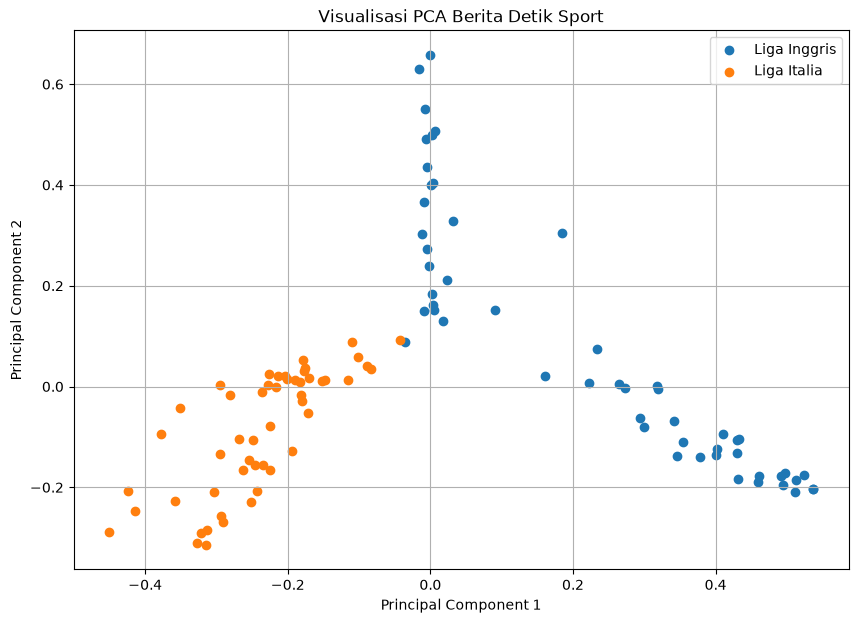

In [35]:
plt.figure(figsize=(10, 7))

for kategori in df_pca["kategori"].unique():

    data = df_pca[
        df_pca["kategori"] == kategori
    ]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=kategori
    )

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "Visualisasi PCA Berita Detik Sport"
)

plt.legend()

plt.grid(True)

plt.show()

In [36]:
df_scraping.to_csv(
    "hasil_preprocessing_detik_sport.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Hasil preprocessing berhasil disimpan."
)

Hasil preprocessing berhasil disimpan.


In [37]:
df_pca.to_csv(
    "hasil_pca_detik_sport.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Hasil PCA berhasil disimpan."
)

Hasil PCA berhasil disimpan.


In [38]:
df_tfidf.to_csv(
    "hasil_tfidf_detik_sport.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Hasil TF-IDF berhasil disimpan."
)

Hasil TF-IDF berhasil disimpan.


In [39]:
import pandas as pd
import json

df = pd.read_csv("hasil_preprocessing_detik_sport.csv")

df.to_json(
    "hasil_preprocessing_detik_sport.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("JSON berhasil dibuat!")
print("Jumlah data:", len(df))

JSON berhasil dibuat!
Jumlah data: 104


In [40]:
import pandas as pd

df = pd.read_csv("hasil_tfidf_detik_sport.csv")

df.to_json(
    "hasil_tfidf_detik_sport.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("Jumlah data:", len(df))
print("Jumlah kolom:", len(df.columns))

Jumlah data: 104
Jumlah kolom: 2501


In [41]:
import pandas as pd

df = pd.read_csv("hasil_pca_detik_sport.csv")

df.to_json(
    "hasil_pca_detik_sport.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("Jumlah data:", len(df))
print("Kolom:", df.columns.tolist())

Jumlah data: 104
Kolom: ['PC1', 'PC2', 'judul', 'kategori', 'isi', 'url']
